In [2]:
import dpluspy 
import numpy as np
import pickle

In [4]:
u_bar = 1.1221531631721093e-08
bins = np.logspace(-6, -2, 17)
label_file = "../../vcf_files/populations_sub"

In [ ]:
# Parse with Bherer recombination maps

sums = {}
naive_sums = {}

for chrom in range(1, 23):
    vcf_fname = f"../../vcf_files/merged/merged.variants.chr{chrom}.vcf.gz"
    rec_fname = f"../../recombination_maps/Bherer_b37/sexavg_chr{chrom}.txt.gz"
    mut_fname = f"../../mutation_maps/roulette_b37/roulette_b37_chr{chrom}.npy"
    bed_fname = f"../../bed_files/filterbed_1e-4M_exon_buffer/mask_chr{chrom}.bed.gz"
    interval_fname = f"../../intervals/1e-4_exon_buffer_1.3Mb/intervals_chr{chrom}.txt"
    
    _sums = dpluspy.parsing.parse_stats(
        vcf_fname,
        bed_file=bed_fname,
        rec_map_file=rec_fname,
        mut_map_file=mut_fname,
        interval_file=interval_fname,
        pos_col="pos",
        map_col="cM",
        r_bins=bins,
        chrom=chrom,
        u_bar=u_bar,
        label_file=label_file
    )
    sums.update(_sums)
    with open(f"raw_sums/sums_Bherer_weighted_chr_{chrom}.pkl", "wb") as fout:
        pickle.dump(_sums, fout)

    _naive_sums = dpluspy.parsing.parse_stats(
        vcf_fname,
        bed_file=bed_fname,
        rec_map_file=rec_fname,
        interval_file=interval_fname,
        pos_col="pos",
        map_col="cM",
        r_bins=bins,
        chrom=chrom,
        label_file=label_file,
        get_denoms=False
    )
    naive_sums.update(_naive_sums)
    with open(f"raw_sums/sums_Bherer_naive_chr_{chrom}.pkl", "wb") as fout:
        pickle.dump(_naive_sums, fout)

[2025-09-09 11:17:41] Computed stats within chrom 1 interval 0 1-7047600
[2025-09-09 11:17:43] Computed stats between chrom 1 intervals 0 1-118298144-118298144
[2025-09-09 11:17:43] Computed stats within chrom 1 interval 1 7047600-14672369
[2025-09-09 11:17:45] Computed stats between chrom 1 intervals 1 7047600-118298144-118298144
[2025-09-09 11:17:46] Computed stats within chrom 1 interval 2 14672369-21688374
[2025-09-09 11:17:47] Computed stats between chrom 1 intervals 2 14672369-118298144-118298144
[2025-09-09 11:17:48] Computed stats within chrom 1 interval 3 21688374-30997738
[2025-09-09 11:17:50] Computed stats between chrom 1 intervals 3 21688374-118298144-118298144
[2025-09-09 11:17:50] Computed stats within chrom 1 interval 4 30997738-38897784
[2025-09-09 11:17:52] Computed stats between chrom 1 intervals 4 30997738-118298144-118298144
[2025-09-09 11:17:53] Computed stats within chrom 1 interval 5 38897784-48587016
[2025-09-09 11:17:54] Computed stats between chrom 1 interval

In [7]:
naive_sums = {}
sums = {}
for chrom in range(1, 23):
    with open(f"raw_sums/sums_Bherer_weighted_chr_{chrom}.pkl", "rb") as fin:
        sums.update(pickle.load(fin))
    with open(f"raw_sums/sums_Bherer_naive_chr_{chrom}.pkl", "rb") as fin:
        naive_sums.update(pickle.load(fin))

for region in sums:
    naive_sums[region]["denoms"] = sums[region]["denoms"]
        
pop_ids = sums[next(iter(sums))]["pop_ids"]
weighted_Bherer_stats, weighted_Bherer_varcovs = \
    dpluspy.bootstrapping.bootstrap_stats(sums)
weighted_Bherer_bootreps = dpluspy.bootstrapping.get_bootstrap_reps(sums)
data = {
    "means": weighted_Bherer_stats, 
    "varcovs": weighted_Bherer_varcovs,
    "bootreps": weighted_Bherer_bootreps,
    "bins": bins,
    "pop_ids": pop_ids
}
with open("stats_Bherer_weighted.pkl", "wb") as fout:
    pickle.dump(data, fout)

naive_Bherer_stats, naive_Bherer_varcovs = dpluspy.bootstrapping.bootstrap_stats(naive_sums)
naive_Bherer_bootreps = dpluspy.bootstrapping.get_bootstrap_reps(naive_sums)
data = {
    "means": naive_Bherer_stats, 
    "varcovs": naive_Bherer_varcovs,
    "bootreps": naive_Bherer_bootreps,
    "bins": bins,
    "pop_ids": pop_ids
}
with open("stats_Bherer_naive.pkl", "wb") as fout:
    pickle.dump(data, fout)

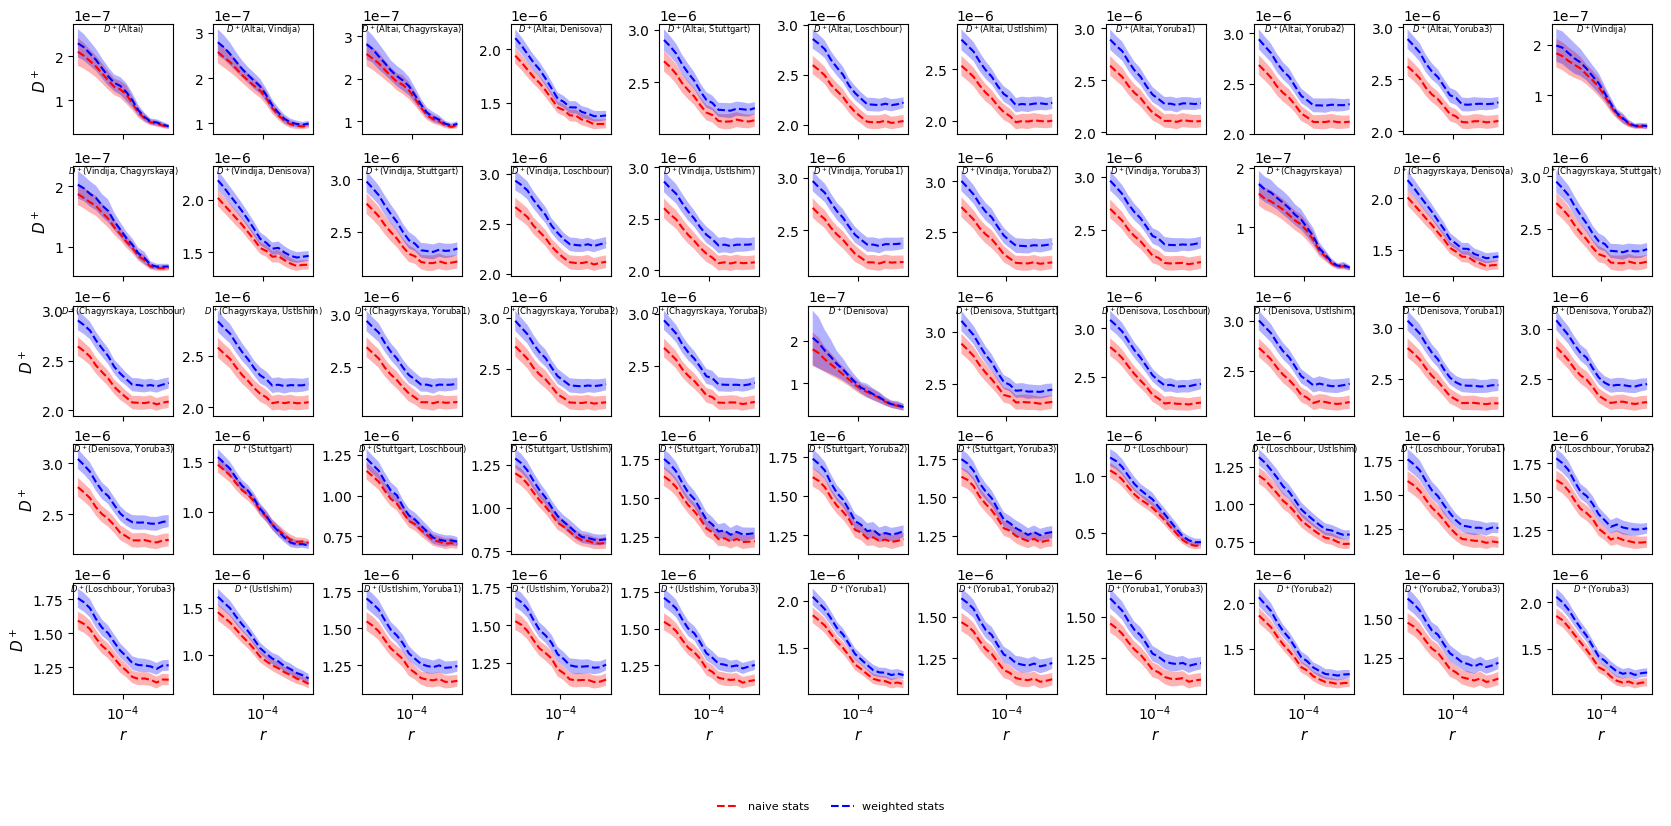

In [28]:
dpluspy.plotting.plot_D_plus_curves(
    means=[naive_Bherer_stats, weighted_Bherer_stats],
    varcovs=[naive_Bherer_varcovs, weighted_Bherer_varcovs],
    bins=bins,
    pop_ids=pop_ids,
    ax_size=1.5,
    cols=11,
    colors=["red", "blue"],
    labels=["naive stats", "weighted stats"],
    out="figures/Bherer_weighting_curve_comp.pdf"
)

In [ ]:
# Zhou JHS recombination maps

sums = {}
naive_sums = {}

for chrom in range(1, 23):
    vcf_fname = f"../../vcf_files/merged/merged.variants.chr{chrom}.vcf.gz"
    rec_fname = f"../../recombination_maps/Zhou_b37/JHS.map/JHS.chr{chrom}.1000.plinkmap.txt"
    mut_fname = f"../../mutation_maps/roulette_b37/roulette_b37_chr{chrom}.npy"
    bed_fname = f"../../bed_files/filterbed_1e-4M_exon_buffer/mask_chr{chrom}.bed.gz"
    interval_fname = f"../../intervals/1e-4_exon_buffer_1.3Mb/intervals_chr{chrom}.txt"
    
    _sums = dpluspy.parsing.parse_stats(
        vcf_fname,
        bed_file=bed_fname,
        rec_map_file=rec_fname,
        mut_map_file=mut_fname,
        interval_file=interval_fname,
        pos_col="Position(bp)",
        map_col="Map(cM)",
        r_bins=bins,
        chrom=chrom,
        u_bar=u_bar,
        label_file=label_file
    )
    sums.update(_sums)
    with open(f"raw_sums/sums_ZhouJHS_weighted_chr_{chrom}.pkl", "wb") as fout:
        pickle.dump(_sums, fout)

    _naive_sums = dpluspy.parsing.parse_stats(
        vcf_fname,
        bed_file=bed_fname,
        rec_map_file=rec_fname,
        interval_file=interval_fname,
        pos_col="Position(bp)",
        map_col="Map(cM)",
        r_bins=bins,
        chrom=chrom,
        label_file=label_file,
        get_denoms=False
    )
    with open(f"raw_sums/sums_ZhouJHS_naive_chr_{chrom}.pkl", "wb") as fout:
        pickle.dump(_naive_sums, fout)

[2025-09-09 12:30:31] Computed stats within chrom 9 interval 0 1-3777549
[2025-09-09 12:30:32] Computed stats between chrom 9 intervals 0 1-38099592-38099592
[2025-09-09 12:30:32] Computed stats within chrom 9 interval 1 3777549-8956561
[2025-09-09 12:30:33] Computed stats between chrom 9 intervals 1 3777549-38099592-38099592
[2025-09-09 12:30:34] Computed stats within chrom 9 interval 2 8956561-11606480
[2025-09-09 12:30:35] Computed stats between chrom 9 intervals 2 8956561-38099592-38099592
[2025-09-09 12:30:36] Computed stats within chrom 9 interval 3 11606480-15101830
[2025-09-09 12:30:37] Computed stats between chrom 9 intervals 3 11606480-38099592-38099592
[2025-09-09 12:30:37] Computed stats within chrom 9 interval 4 15101830-20254205
[2025-09-09 12:30:38] Computed stats between chrom 9 intervals 4 15101830-38099592-38099592
[2025-09-09 12:30:39] Computed stats within chrom 9 interval 5 20254205-24484566
[2025-09-09 12:30:40] Computed stats between chrom 9 intervals 5 20254205-

In [13]:
naive_sums = {}
sums = {}
for chrom in range(1, 23):
    with open(f"raw_sums/sums_ZhouJHS_weighted_chr_{chrom}.pkl", "rb") as fin:
        sums.update(pickle.load(fin))
    with open(f"raw_sums/sums_ZhouJHS_naive_chr_{chrom}.pkl", "rb") as fin:
        naive_sums.update(pickle.load(fin))

for region in sums:
    naive_sums[region]["denoms"] = sums[region]["denoms"]

        
pop_ids = sums[next(iter(sums))]["pop_ids"]
weighted_ZhouJHS_stats, weighted_ZhouJHS_varcovs = \
    dpluspy.bootstrapping.bootstrap_stats(sums)
weighted_ZhouJHS_bootreps = dpluspy.bootstrapping.get_bootstrap_reps(sums)
data = {
    "means": weighted_ZhouJHS_stats, 
    "varcovs": weighted_ZhouJHS_varcovs,
    "bootreps": weighted_ZhouJHS_bootreps,
    "bins": bins,
    "pop_ids": pop_ids
}
with open("stats_ZhouJHS_weighted.pkl", "wb") as fout:
    pickle.dump(data, fout)

naive_ZhouJHS_stats, naive_ZhouJHS_varcovs = dpluspy.bootstrapping.bootstrap_stats(naive_sums)
naive_ZhouJHS_bootreps = dpluspy.bootstrapping.get_bootstrap_reps(naive_sums)
data = {
    "means": naive_ZhouJHS_stats, 
    "varcovs": naive_ZhouJHS_varcovs,
    "bootreps": naive_ZhouJHS_bootreps,
    "bins": bins,
    "pop_ids": pop_ids
}
with open("stats_ZhouJHS_naive.pkl", "wb") as fout:
    pickle.dump(data, fout)

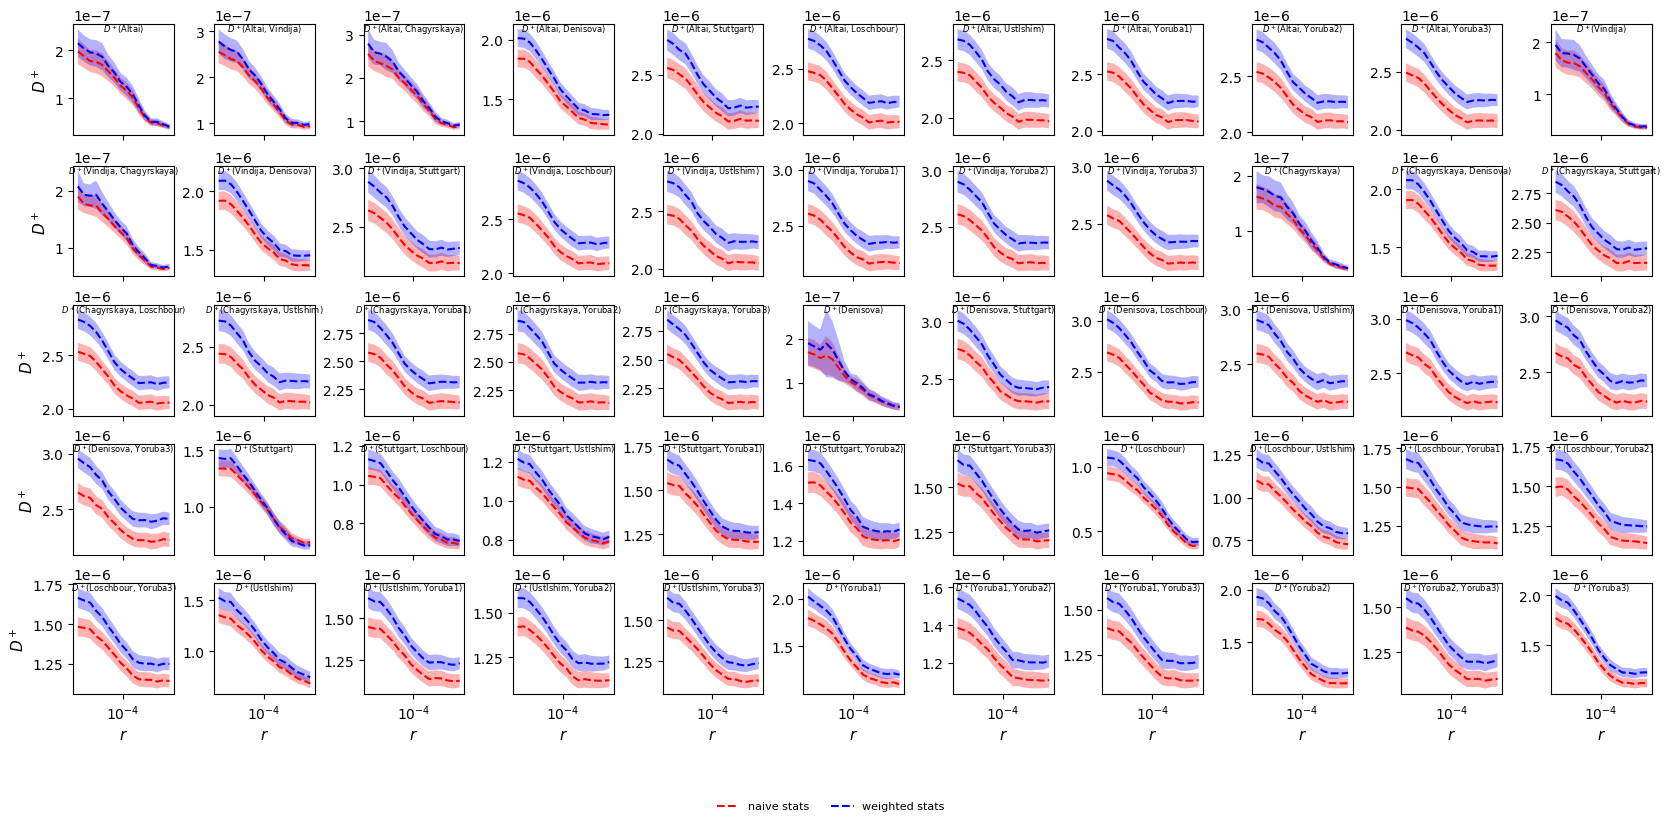

In [29]:
dpluspy.plotting.plot_D_plus_curves(
    means=[naive_ZhouJHS_stats, weighted_ZhouJHS_stats],
    varcovs=[naive_ZhouJHS_varcovs, weighted_ZhouJHS_varcovs],
    bins=bins,
    pop_ids=pop_ids,
    ax_size=1.5,
    cols=11,
    colors=["red", "blue"],
    labels=["naive stats", "weighted stats"],
    out="figures/ZhouJHS_weighting_curve_comp.pdf"
)

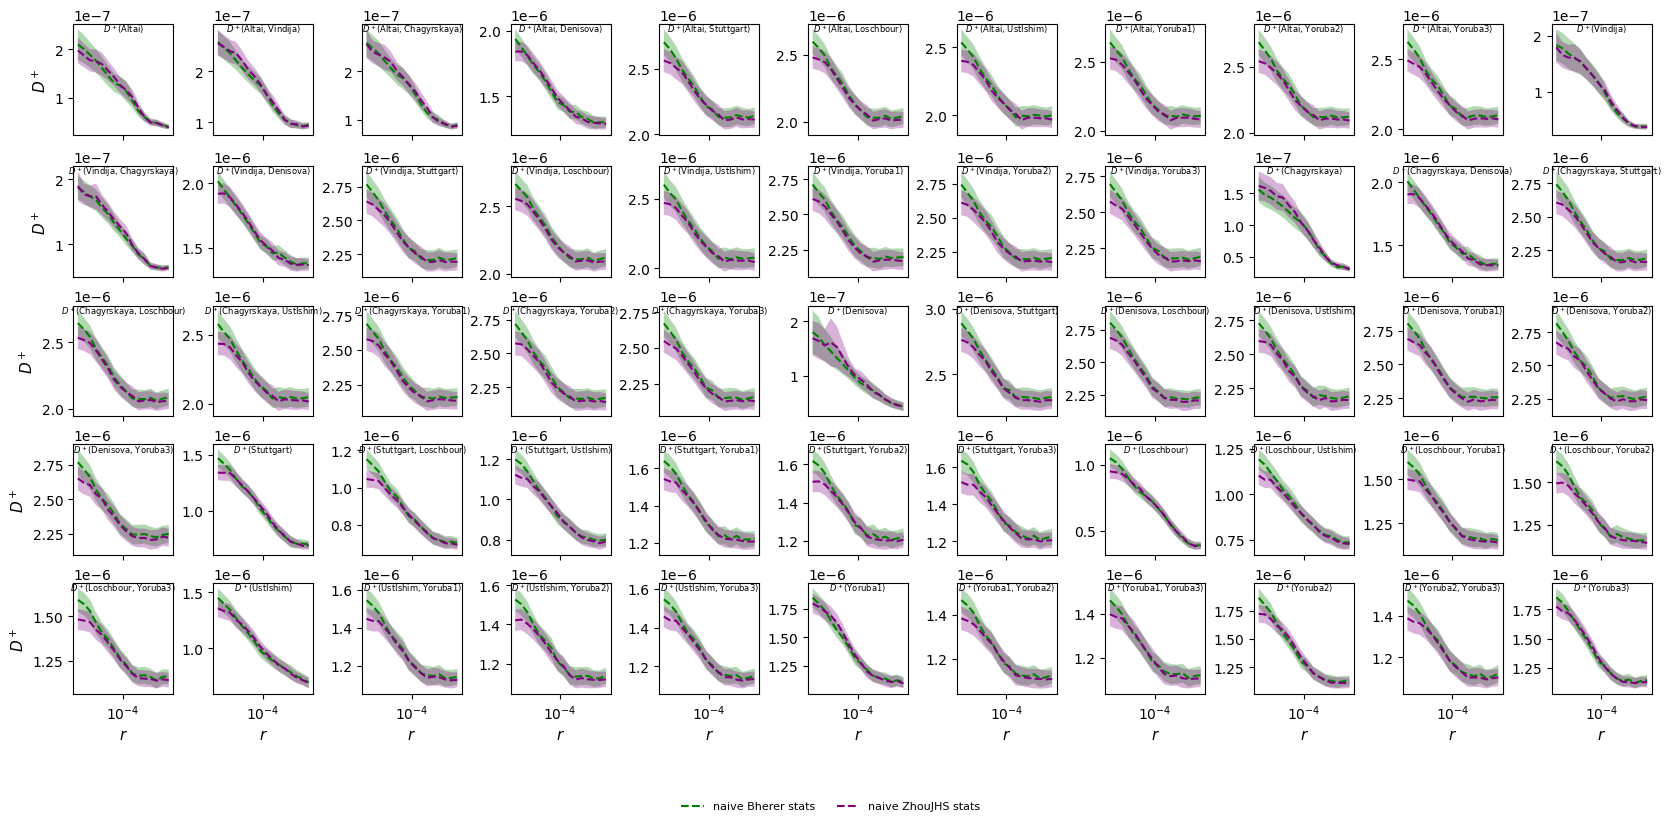

In [26]:
dpluspy.plotting.plot_D_plus_curves(
    means=[naive_Bherer_stats, naive_ZhouJHS_stats],
    varcovs=[naive_Bherer_varcovs, naive_ZhouJHS_varcovs],
    bins=bins,
    pop_ids=pop_ids,
    ax_size=1.5,
    cols=11,
    colors=["green", "purple"],
    labels=["naive Bherer stats", "naive ZhouJHS stats"],
    out="figures/naive_map_curve_comp.pdf"
)

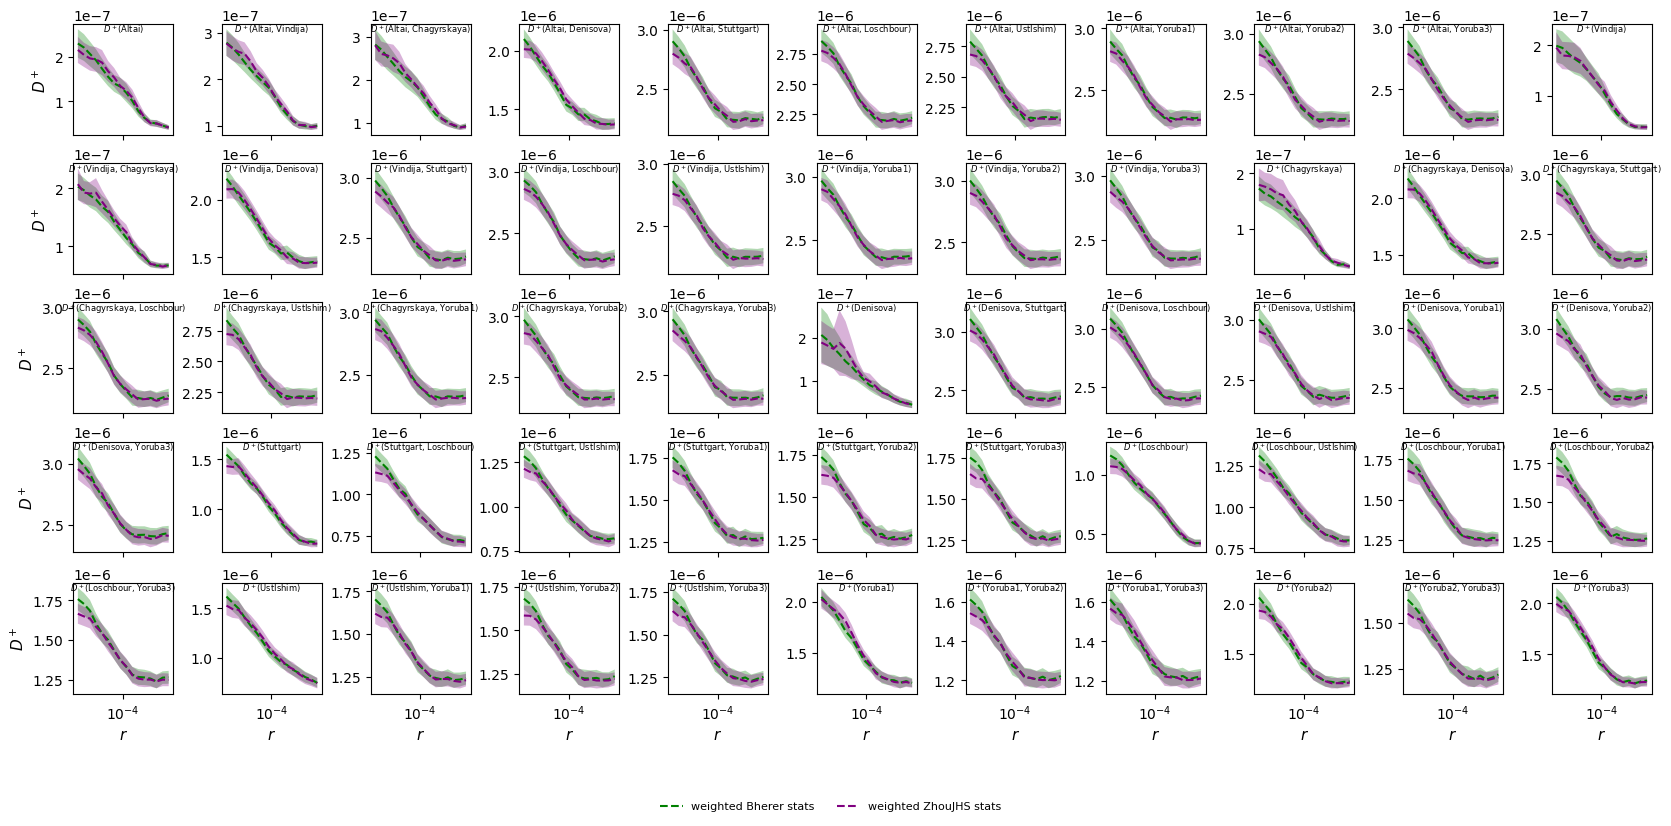

In [24]:
dpluspy.plotting.plot_D_plus_curves(
    means=[weighted_Bherer_stats, weighted_ZhouJHS_stats],
    varcovs=[weighted_Bherer_varcovs, weighted_ZhouJHS_varcovs],
    bins=bins,
    pop_ids=pop_ids,
    ax_size=1.5,
    cols=11,
    colors=["green", "purple"],
    labels=["weighted Bherer stats", "weighted ZhouJHS stats"],
    out="figures/weighted_map_curve_comp.pdf"
)

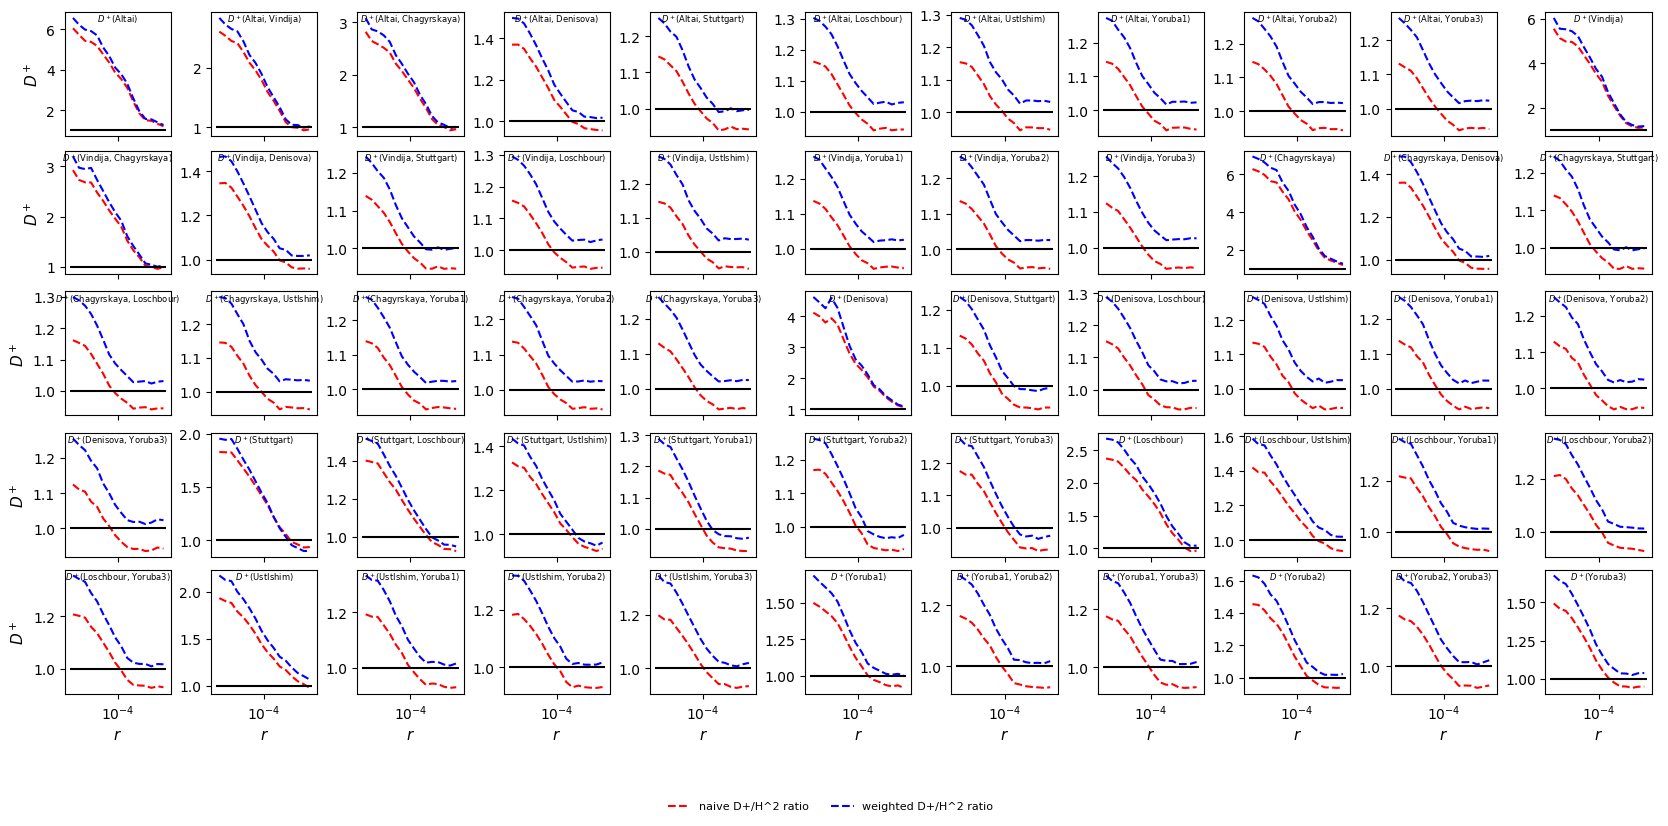

In [23]:
# ratio of D+ / H^2
naive_Bherer_ratio = [x / naive_ZhouJHS_stats[-1] ** 2 for x in 
                      naive_ZhouJHS_stats[:-1]]
weighted_Bherer_ratio = [x / weighted_ZhouJHS_stats[-1] ** 2 for x in 
                      weighted_ZhouJHS_stats[:-1]]

dpluspy.plotting.plot_D_plus_curves(
    means=[naive_Bherer_ratio, weighted_Bherer_ratio],
    varcovs=[naive_ZhouJHS_varcovs, weighted_ZhouJHS_varcovs],
    bins=bins,
    pop_ids=pop_ids,
    ax_size=1.5,
    cols=11,
    colors=["red", "blue"],
    labels=["naive D+/H^2 ratio", "weighted D+/H^2 ratio"],
    hline=1,
    out="figures/ratio_curves_figure_ZhouJHS.pdf"
)